In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

from v2_data_preparation import load_and_prepare_data, slice_by_dates

In [56]:
# Config
precip_fp = '../outputs/dga_precipitation/dga_daily_precip.csv'
model = 'first-year'     # two-years, first-year, second-year

if model == 'two-years':
    predictions_fp1 = '../outputs/predictions/SDH1_2000-2026_two-years.csv'
    predictions_fp2 = '../outputs/predictions/SDH2_2000-2026_two-years.csv'
elif model == 'first-year':
    predictions_fp1 = '../outputs/predictions/SDH1_2000-2026_first-year.csv'
    predictions_fp2 = '../outputs/predictions/SDH2_2000-2026_first-year.csv'
elif model == 'second-year':
    predictions_fp1 = '../outputs/predictions/SDH1_2000-2026_second-year.csv'
    predictions_fp2 = '../outputs/predictions/SDH2_2000-2026_second-year.csv'
else:
    print(f'{model} not supported as model choice')

sdh1ps01_elev = 3782.5  # CS6
sdh2pp01_elev = 3786.9  # CS8

sigma_threshold = 3

In [57]:
# load pp data
precip = load_and_prepare_data(precip_fp, 'date')
sillillica = precip['sillillica_precip_mm'].dropna()
sillillica = slice_by_dates(sillillica, '2012', '2013')

coyacagua = precip['coyacagua_precip_mm'].dropna()
coyacagua_clip = slice_by_dates(coyacagua, sillillica.index.min(), sillillica.index.max())

In [58]:
# load predictions data
pred1 = load_and_prepare_data(
    filepath=predictions_fp1,
    index_col='Timestamps'
)
pred1_diff = pred1.diff()

# clip to sillillica data range
pred1_clip = slice_by_dates(pred1, sillillica.index.min(), sillillica.index.max())
pred1_diff_clip = slice_by_dates(pred1_diff, sillillica.index.min(), sillillica.index.max())

In [59]:
# load predictions data
pred2 = load_and_prepare_data(
    filepath=predictions_fp2,
    index_col='Timestamps'
)
pred2_diff = pred2.diff()

# clip to sillillica data range
pred2_clip = slice_by_dates(pred2, sillillica.index.min(), sillillica.index.max())
pred2_diff_clip = slice_by_dates(pred2_diff, sillillica.index.min(), sillillica.index.max())

#### SDH1

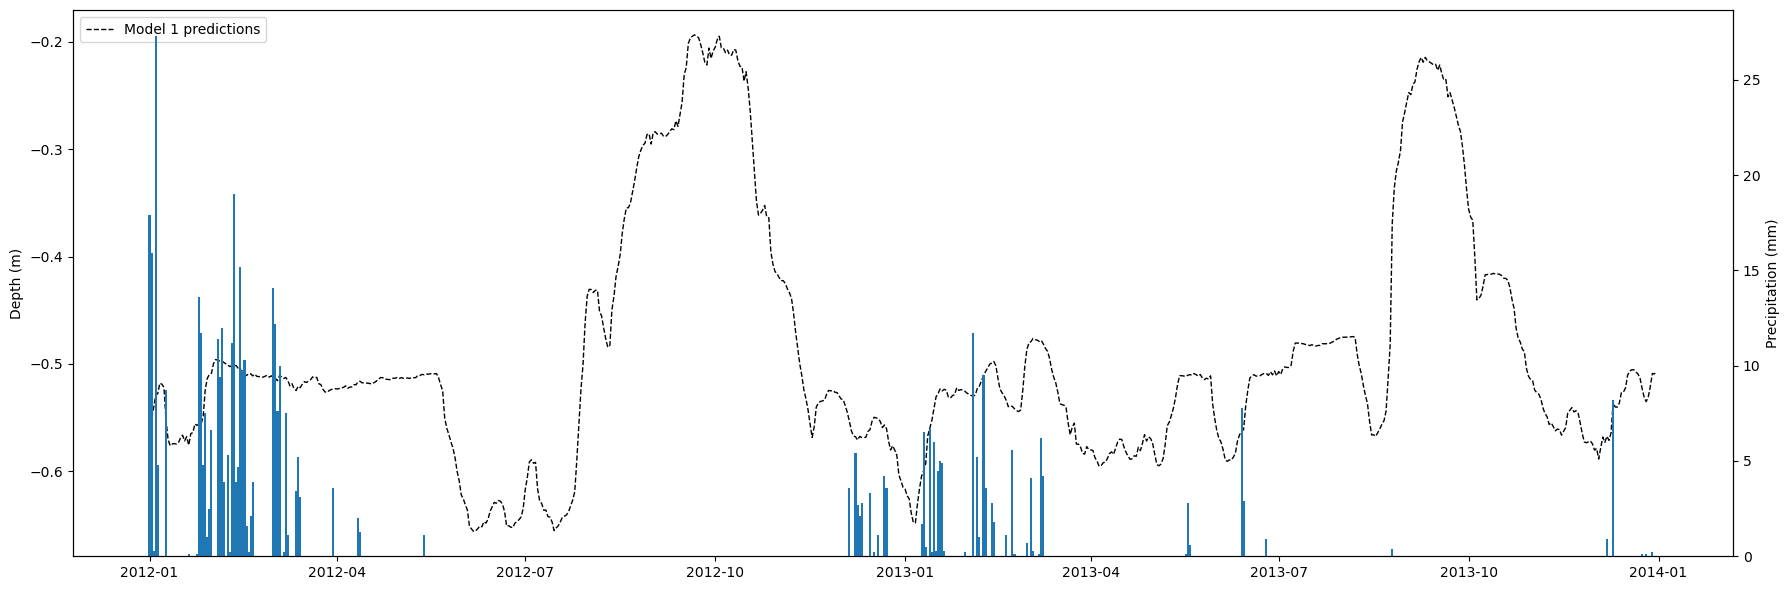

In [60]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(pred1_clip.index, pred1_clip,
         label='Model 1 predictions', color='black', linewidth=1, linestyle='--')

ax2 = ax1.twinx()
ax2.bar(sillillica.index, sillillica, width=1, label='Sillillica')

ax1.set_ylabel('Depth (m)')
ax2.set_ylabel('Precipitation (mm)')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

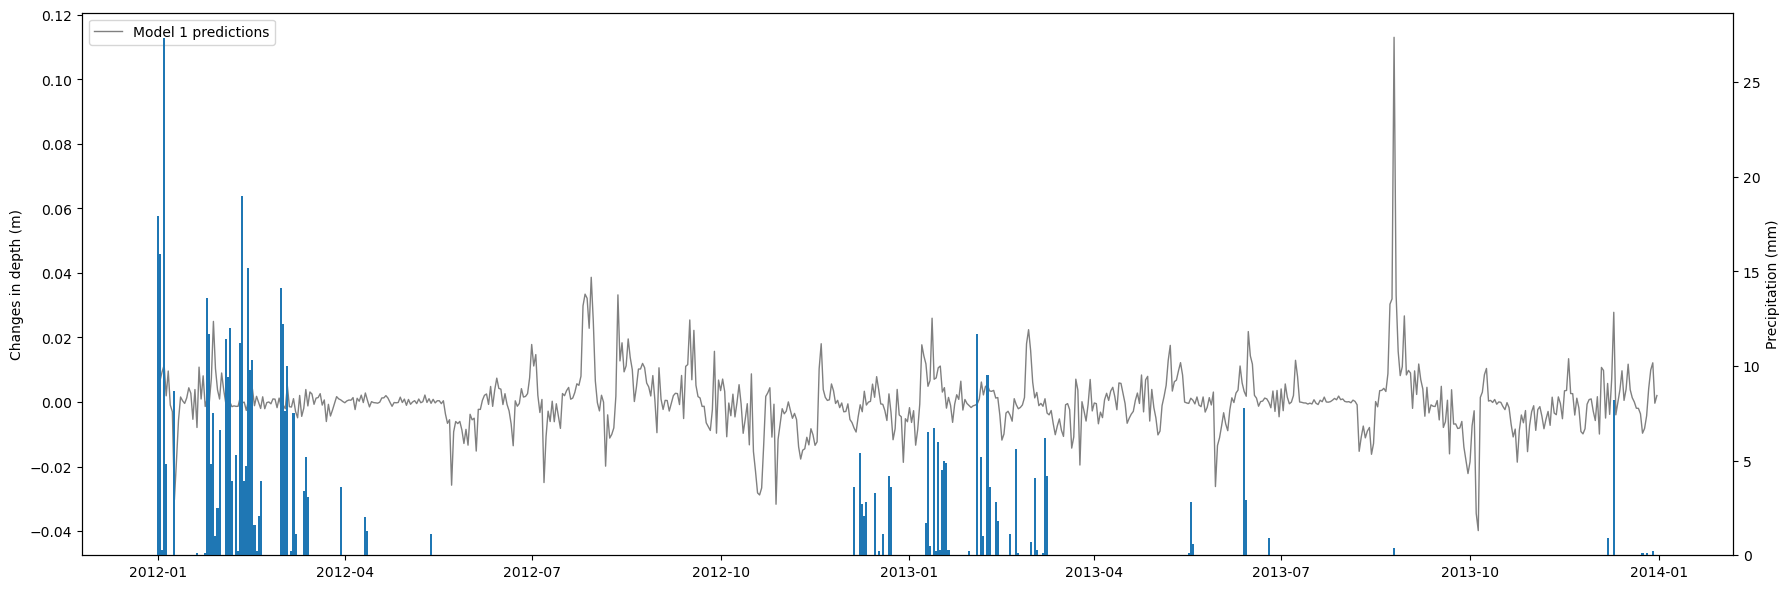

In [61]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(pred1_diff_clip.index, pred1_diff_clip,
         label='Model 1 predictions', color='gray', linewidth=1)

ax2 = ax1.twinx()
ax2.bar(sillillica.index, sillillica, width=1, label='Sillillica')

ax1.set_ylabel('Changes in depth (m)')
ax2.set_ylabel('Precipitation (mm)')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

#### SDH2

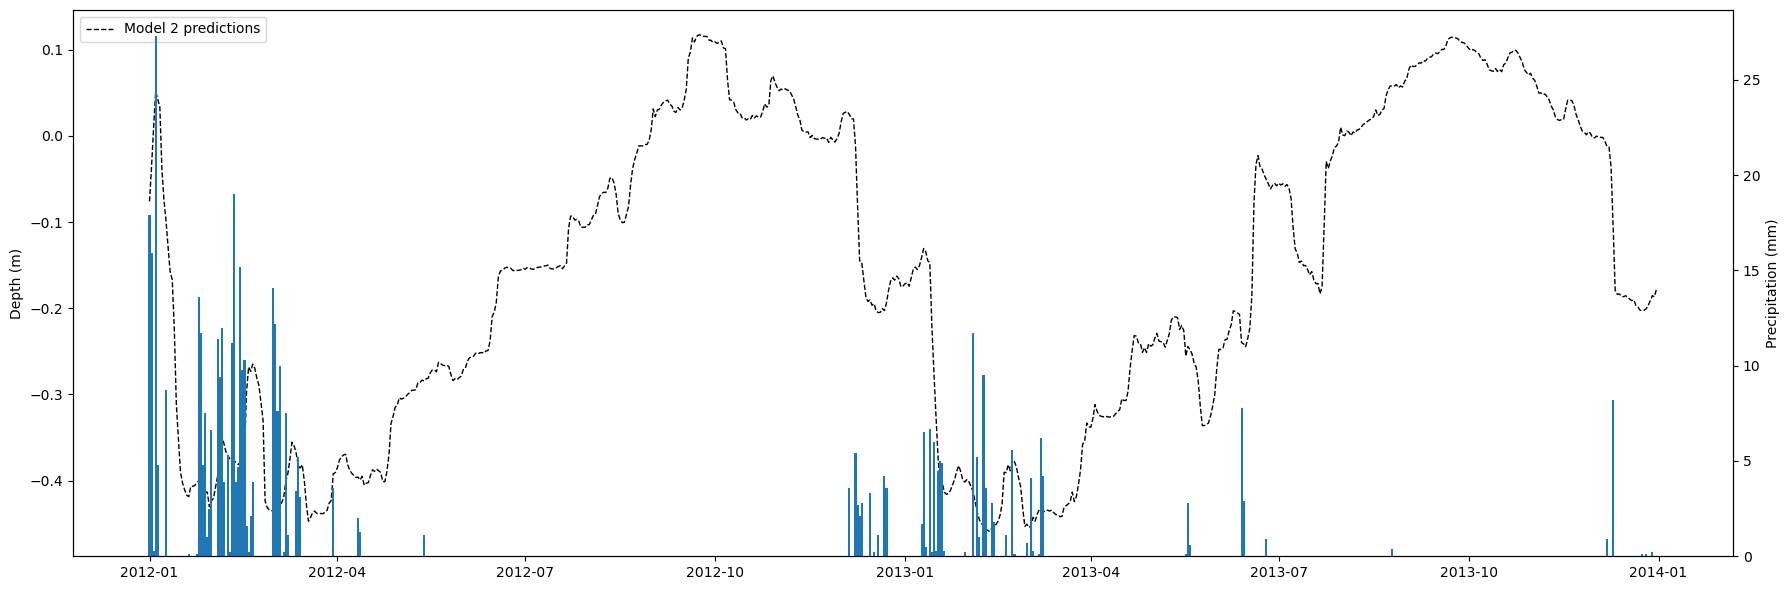

In [62]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(pred2_clip.index, pred2_clip,
         label='Model 2 predictions', color='black', linewidth=1, linestyle='--')

ax2 = ax1.twinx()
ax2.bar(sillillica.index, sillillica, width=1, label='Sillillica')

ax1.set_ylabel('Depth (m)')
ax2.set_ylabel('Precipitation (mm)')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

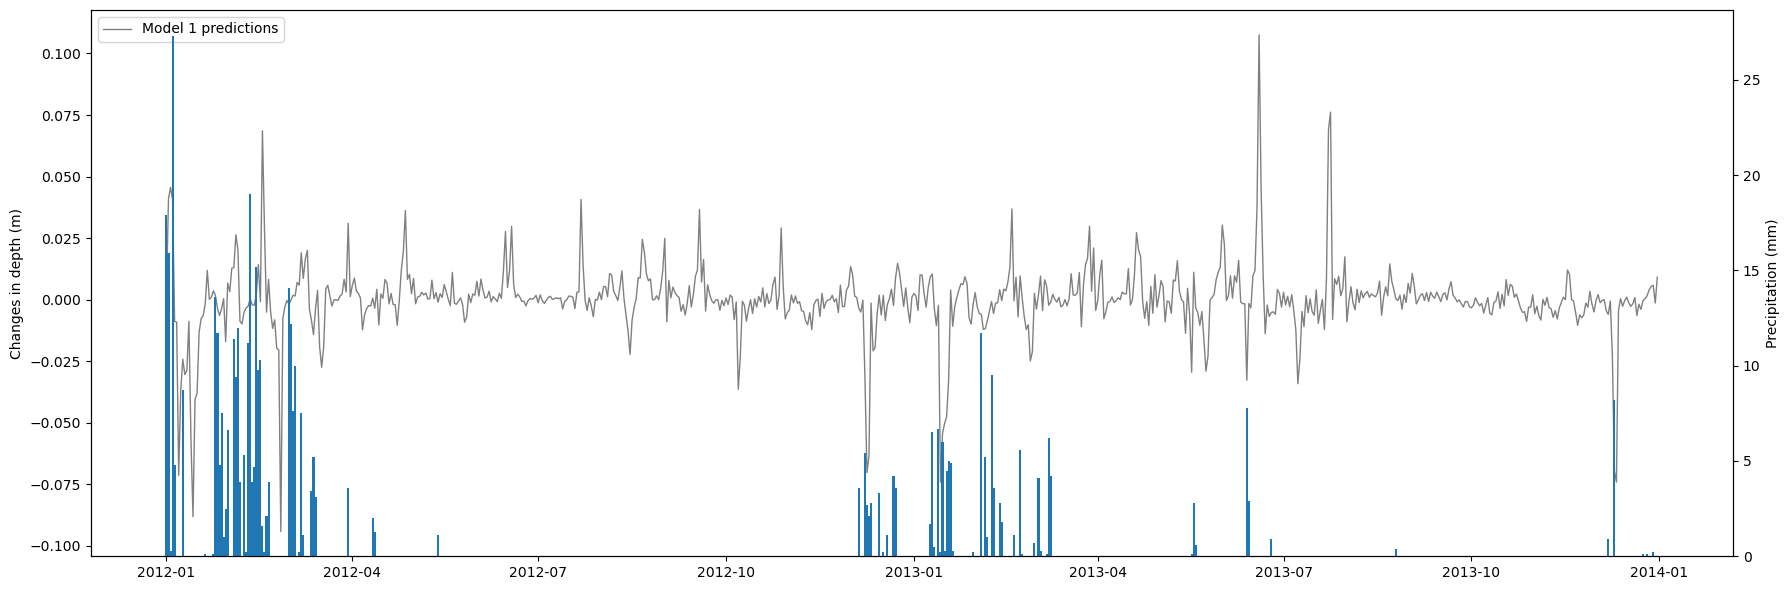

In [63]:
fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.plot(pred2_diff_clip.index, pred2_diff_clip,
         label='Model 1 predictions', color='gray', linewidth=1)

ax2 = ax1.twinx()
ax2.bar(sillillica.index, sillillica, width=1, label='Sillillica')

ax1.set_ylabel('Changes in depth (m)')
ax2.set_ylabel('Precipitation (mm)')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()